# Exercises

## Modeling, Linear Regression and kNN

<ol>
<li> A hospital service treats patients with a degenerative disease that takes some years to show symptons after the patient has a positive diagnosis. It is important for each patient to start taking a specific drug one year before the symptoms appear and it is not useful to take the drug before that. Taking the drug one year before symptoms gives the patient a better quality of life. On the other hand, the drug has a very high cost and if the patient takes it too long before needed this is a heavy burden for the healthcare budget. The service has data that describes each patient and with clinical and demographic attributes associating each record with the time between diagnosis and symptoms onset (symptoms start). Identify:</li>

    a. the business problem;

    R: Administrar o medicamento o mais próximo de um ano antes de começar   
       a aparecer sintomas (para ter o tratamento efetivo, e evitar custos         desnecessários ao dar o meidacamento antes do primeiro ano)
    
    b. the business success criteria;

    R: Aqui o sucesso representa definir um 'método' que efetivamente     determine a altura 'correta' que a pessoa com uma doença degenerativa deve tomar o medicamento (aqui altura 'correta' é um ano antes de aparecerem os sintomas)
    
    c. the machine learning type of task;

    R: Supervised learning, porque o objetivo é **prever algo** (sempre que temos uma tarefa de prever algo, usamos Supervised Learning). Não é Unsupervised Learning, porque no unsupervised learning o objetivo é extrair padrões genéricos 

    d. the machine learning problem;

    R: Saber se um individui com degenerativa deve começar a tomar o medicamento ou não (neste caso queremos que ele tome exatamente um ano antes de começar a aparecer sintomas)
    
    e. the machine learning success criteria.

    R: Utilizar métricas como:
        -> Mean Absolute Error (MAE)
        -> Mean Squared Error (MSE)
        -> Root Mean Squared Error (RMSE)
        -> R-Squared (R^2)

    
    

<li> Suppose we have a regression problem with 4 independent variables and one target variable:</li>

    a. when can we try a linear regression approach?

    R: Podemos tentar uma aproximação de Linear regression quando temos:
        -> Linearity
        -> Independence
        -> Homoscedasticity
        -> Normality of residuals
        -> No multicollinearity
    
    
    b. which regression model obtains an R-square of 0?

    R: O R-quadrado representa a percentagem da variação da variável dependente que um modelo linear explica. 0% representa um modelo que não explica nenhuma variação da variável resposta em torno de sua média.
    
    c. how could a model obtain a negative R-square?

    R: Um modelo pode obter um valor de R² negativo quando suas previsões são piores do que simplesmente estimar o valor médio da variável alvo. Isso ocorre quando os erros do modelo são grandes, geralmente porque o modelo não se ajusta bem aos dados, não possui um termo de intercepto ou está sendo avaliado em dados com os quais não foi treinado.
    
    d. if all variables have a negative correlation with the target, what would be the signal of the coefficients?


    R:  Uma correlação negativa descreve a extensão em que duas variáveis se movem em direções opostas. Um aumento em X está associado a uma diminuição em Y para duas variáveis, X e Y.Se você observar coeficientes positivos para variáveis que são negativamente correlacionadas com a variável alvo em um modelo de regressão múltipla, isso geralmente indica multicolinearidade entre as variáveis preditoras.

</ol>  

<li> Download the classic <a href=https://www.kaggle.com/datasets/uciml/autompg-dataset>"auto-mpg-dataset"</a> and use linear regression for predicting the car consumption in miles per gallon (mpg).</li>

In [1]:
# Enable autocomplete
%config IPCompleter.greedy=True

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd


df = pd.read_csv('DataSets/auto-mpg.csv')

df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

    a. Visualize the plots of the independent variables against the dependent variable "mpg". Which variable seems better for simple regression?


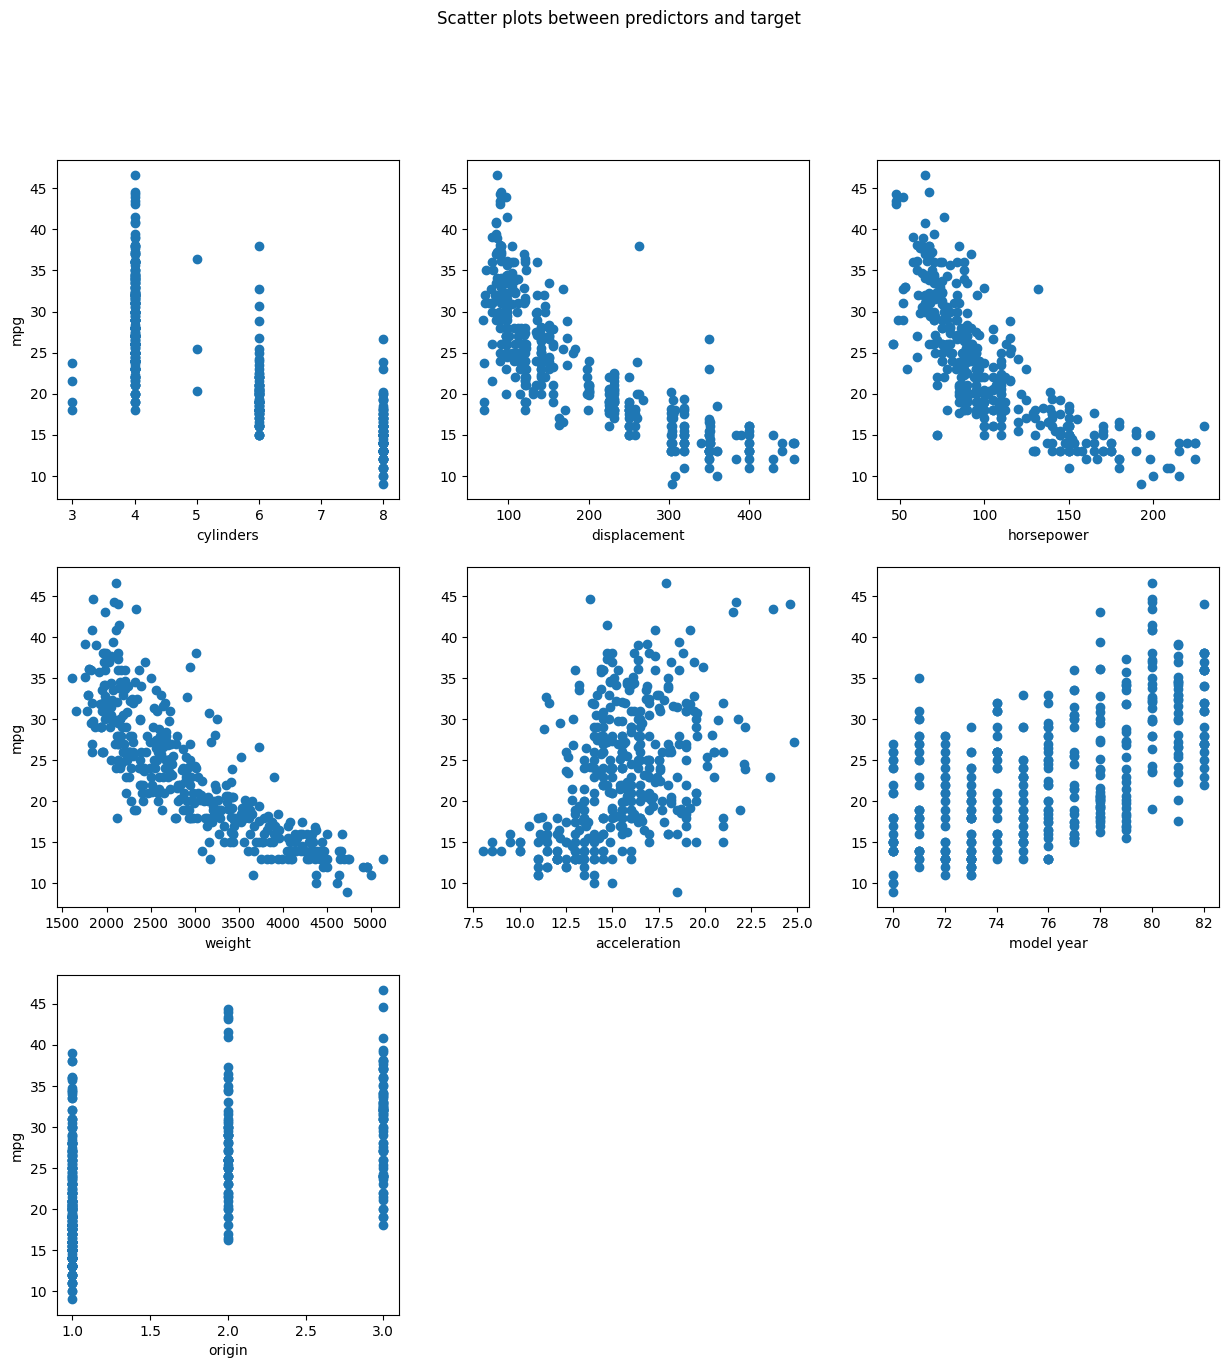

In [ ]:
## Ajustar o plot porque não fica bem 
predictors = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']
x = np.array(df.loc[:,predictors])
y = np.array(df.loc[:,'mpg'])
n_cols = 3
n_rows = (len(predictors) + n_cols - 1) // n_cols

def horsepowerShrink(v,t):
    return v/100

fig, sc = plt.subplots(n_rows,n_cols, figsize=(15, 5 * n_rows))
fig.suptitle('Scatter plots between predictors and target')

for i in range(len(predictors)):
    r = i // n_cols
    c = i % n_cols
    #if predictors[i] == 'horsepower':
        #sc[r,c].xaxis.set_major_formatter(plt.FuncFormatter(horsepowerShrink))
     
    sc[r,c].set(xlabel=predictors[i])
    sc[r,c].scatter(x[:,i],y) 
    sc[r,c].set(ylabel='mpg' if c == 0 else '') # Label Y apenas na primeira coluna


# Remove eixos vazios se houver
if len(predictors) < n_rows * n_cols:
    for i in range(len(predictors), n_rows * n_cols):
        r = i // n_cols
        c = i % n_cols
        fig.delaxes(sc[r,c])


> car consumption in miles per gallon (mpg)

* Ao fazer o plot de **Predictor Variables vs Target Variable** (figuras acima), podemos concluir o seguinte:
    * ```cylinders```vs ```mpg```
        * Não tem uma relação linear entre o número de Cylenders e valor de mpg
    * ```displacement``` vs ```mpg```
        * Existe uma **correlação negativa**
        * **À medida que o displacement aumenta o mpg diminui**
    * ```horsepower``` vs ```mpg```
        * Existe uma **correlação negativa**
        * **À medida que o horsepower aumenta o mpg diminui**
    * ```weight``` vs ```mpg```
        * Existe uma **correlação negativa**
        * **À medida que o weigth aumenta o mpg diminui**
    * ```acceleration``` vs ```mpg```
        * Existe uma **correlação positiva**
        *  **À medida que o acceleration aumenta o mpg aumenta**
    * ```model year``` vs ```mpg```
        * Existe uma **correlação positva**
        *  **À medida que o model year aumenta o mpg aumenta**
    * ```origin``` vs ```mpg```
        * Existe uma **correlação positiva**
        * **À medida que o origin  aumenta o mpg aumenta**

R: A varíavel que me parece ser mais promessedor para Simple Linear Regression é o **Weight**, porque parece ter um **correlação mais forte** (pontos estão mais juntos) e é **relativamente linear** (quase que forma uma reta)

b. Using the scatter plots try to visualy rank the variables from more promising to less promising. Then obtain R-square for the simple regression done on each variable and check if your intuition was correct.

Visualizando os plots de **Predictor Variable** vs **Target Variable** eu acho que o ranking de variable a mais promessedora à menos promessedora  para Simple Linear Regression é o seguinte (só usei variaveis continuas):

1. weigth
2. displacement
3. horsepower 
4. accelaration



In [ ]:
r2_results = {}
df_aux = df.dropna()
# Loop para testar uma variável de cada vez
for var in predictors:
    
    X_temp = df_aux[[var]].values 
    y_temp = df_aux['mpg'].values
    
    # Criar e treinar o modelo linear simples
    model = LinearRegression()
    model.fit(X_temp, y_temp)
    
    # Calcular o R^2 (score)
    r2 = model.score(X_temp, y_temp)
    
    # Guardar o resultado
    r2_results[var] = r2

# Converter para DataFrame para visualizar melhor e ordenar
results_df = pd.DataFrame(list(r2_results.items()), columns=['Predictor', 'R2_Score'])
results_df = results_df.sort_values(by='R2_Score', ascending=False)

print(results_df)

      Predictor  R2_Score
3        weight  0.692630
1  displacement  0.648229
2    horsepower  0.605948
0     cylinders  0.604689
5    model year  0.337028
6        origin  0.319461
4  acceleration  0.179207


    c. Plot the regression line against the scatter plot for each variable.

Gerando gráficos individuais...
------------------------------


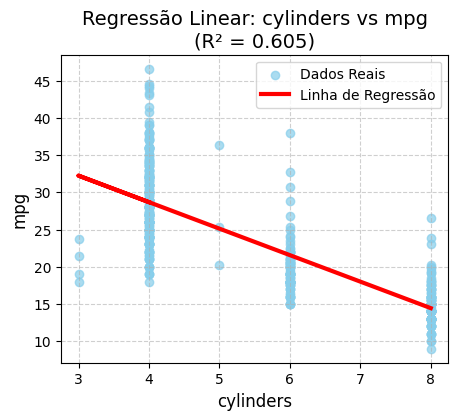

Gráfico para 'cylinders' gerado.
------------------------------


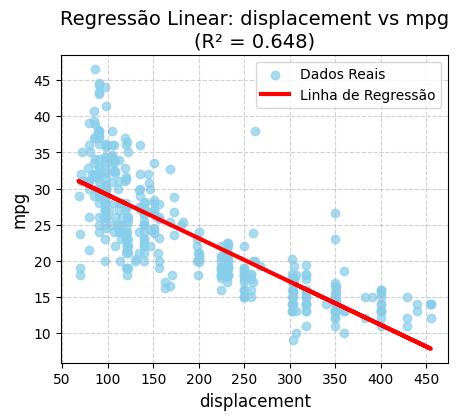

Gráfico para 'displacement' gerado.
------------------------------


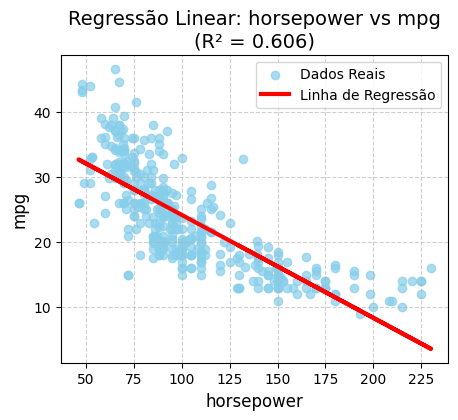

Gráfico para 'horsepower' gerado.
------------------------------


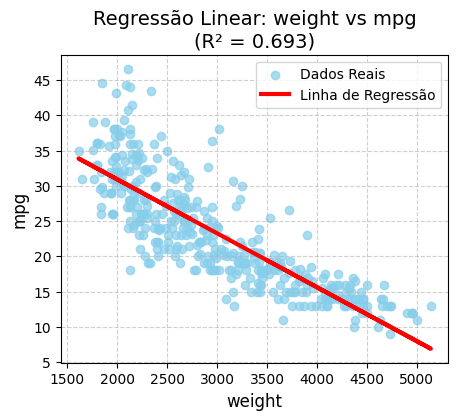

Gráfico para 'weight' gerado.
------------------------------


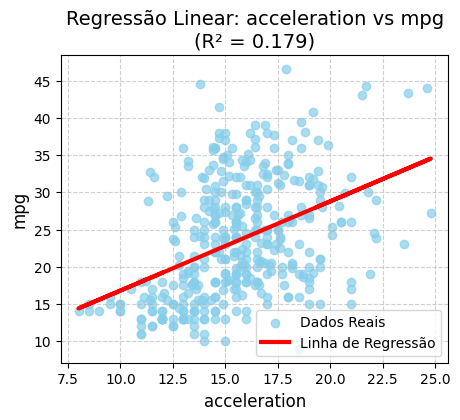

Gráfico para 'acceleration' gerado.
------------------------------


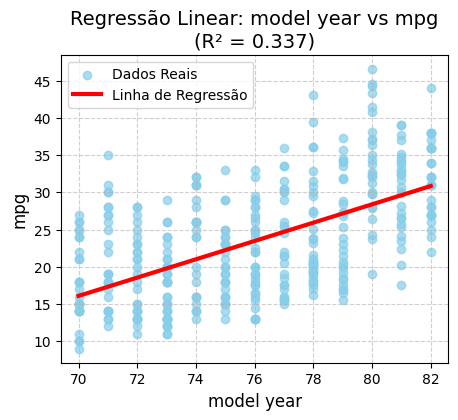

Gráfico para 'model year' gerado.
------------------------------


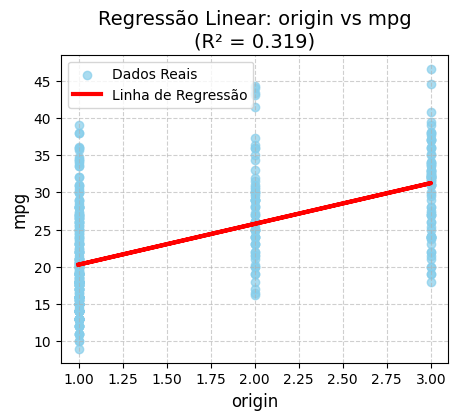

Gráfico para 'origin' gerado.
------------------------------


In [ ]:
df_aux = df.dropna()

print("Gerando gráficos individuais...")
print("-" * 30)

for var in predictors:
    # Preparar dados
    X_temp = df_aux[[var]].values 
    y_temp = df_aux['mpg'].values
    
    # Treinar o modelo
    model = LinearRegression()
    model.fit(X_temp, y_temp)
    
    # Criar a Linha de Previsão
    y_pred = model.predict(X_temp)
    
    # Configurar a nova figura para este gráfico
    plt.figure(figsize=(5, 4)) 
    
    # Scatter Plot
    plt.scatter(X_temp, y_temp, color='skyblue', alpha=0.7, label='Dados Reais')
    
    # Desenhar a Linha de Regressão
    plt.plot(X_temp, y_pred, color='red', linewidth=3, label='Linha de Regressão')
    
    # Formatação
    score = r2_results[var]
    plt.title(f'Regressão Linear: {var} vs mpg\n(R² = {score:.3f})', fontsize=14)
    plt.xlabel(var, fontsize=12)
    plt.ylabel('mpg', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Mostrar o gráfico
    plt.show()
    print(f"Gráfico para '{var}' gerado.")
    print("-" * 30)

    d. Which variables have a positive coefficient? What is the meaning of having a positive or a negative coefficient?

R: Um coeficiente indica-nos a direção da relação entre **Predictor variable** e **Target Variable**, se for positivo vamos ter uma relação "crescente" (i.e. a medida que a **Predictor variable** cresce a **Target Variable** também cresce) e o coefeciente negativo é o contrario. 

Variáveis com Coeficiente positivo (usandos os plots anteriores como auxiliar):

* origin 
* model year 
* accelaration


Variáveis com Coeficiente negativo (usandos os plots anteriores como auxiliar):

* weigth
* horsepower
* displacement
* cylinders


    e. Try multiple regression and compare this R-square with the best ones from simple regression.


In [ ]:
# Fiz apenas muliple linear regression com dois predictors 

predictors = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']
predictors_pairs = []

for i in range(len(predictors)):
    for j in range(i+1,len(predictors),+1):
        predictors_pairs.append([predictors[i],predictors[j]])


r2_results = {}
df_aux = df.dropna()
# print(predictors_pairs)
# Loop para testar uma variável de cada vez
for var in predictors_pairs:
    X_temp = df_aux[var].values 
    y_temp = df_aux['mpg'].values
    
    # Criar e treinar o modelo Multiple linear regression
    model = LinearRegression()
    model.fit(X_temp, y_temp)
    
    # Calcular o R^2 (score)
    r2 = model.score(X_temp, y_temp)
    
    # Guardar o resultado
    pair_name = f"{var[0]} + {var[1]}"  
    r2_results[pair_name] = r2

# Converter para DataFrame para visualizar melhor e ordenar
results_df = pd.DataFrame(list(r2_results.items()), columns=['Predictor_Pair', 'R2_Score'])
results_df = results_df.sort_values(by='R2_Score', ascending=False)
print(results_df)

                 Predictor_Pair  R2_Score
16          weight + model year  0.808180
9     displacement + model year  0.740853
4        cylinders + model year  0.715070
11          horsepower + weight  0.706375
17              weight + origin  0.701961
15        weight + acceleration  0.699698
7         displacement + weight  0.698967
2            cylinders + weight  0.697463
13      horsepower + model year  0.685497
6     displacement + horsepower  0.664329
14          horsepower + origin  0.662046
1        cylinders + horsepower  0.656892
10        displacement + origin  0.656200
0      cylinders + displacement  0.649752
8   displacement + acceleration  0.648528
12    horsepower + acceleration  0.630339
5            cylinders + origin  0.626985
3      cylinders + acceleration  0.605968
20          model year + origin  0.555671
19        acceleration + origin  0.415675
18    acceleration + model year  0.407920


R: O R^2 do melhor modelo de simple linear regression utilizad o weight como predictor e tem o valor igual a 0.692630. No caso de Multiple linear regression, com os predictoris weight + model year, o valor de R^2 é de 0.808180. Neste caso, vemos que multiple linear regression com duas variáveis Predictors, vamos obter um melhor resultado.

    g. Measure the total sum of squares. What is the meaning of this value?

In [ ]:
df_aux = df.dropna()

print("-" * 30)
print("Sum of Squares Regression (SSR) for Simple linear regression models")
for var in predictors:
    X_temp = df_aux[[var]].values 
    y_temp = df_aux['mpg'].values
    
    # Treinar o modelo
    model = LinearRegression()
    model.fit(X_temp, y_temp)

    y_pred = model.predict(X_temp)
    y_mean = np.mean(y_temp)


    SSE = np.sum((y_temp - y_pred)**2) #Sum of Squares Error (SSE)

    SSR = np.sum((y_pred - y_mean)**2) # Sum of Squares Regression (SSR)

    SST = SSE + SSR # Total Sum of Squares (SST)
    print("Predictors = ", var , "\n Models SST = " , SST , "\n Models SSE = " , SSE , "\n Models SSR = " , SSR)

print("-" * 30)
print("Sum of Squares Regression (SSR) for Multiple linear regression models")

# Fiz apenas muliple linear regression com dois predictors 

predictors = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']
predictors_pairs = []
for i in range(len(predictors)):
    for j in range(i+1,len(predictors),+1):
        predictors_pairs.append([predictors[i],predictors[j]])

for var in predictors_pairs:
    X_temp = df_aux[var].values 
    y_temp = df_aux['mpg'].values
    
    model = LinearRegression()
    model.fit(X_temp, y_temp)
    
    SSE = np.sum((y_temp - y_pred)**2) #Sum of Squares Error (SSE)

    SSR = np.sum((y_pred - y_mean)**2) # Sum of Squares Regression (SSR)

    SST = SSE + SSR # Total Sum of Squares (SST)
    print("Predictors = ", var , "\n Models SST = " , SST , "\n Models SSE = " , SSE , "\n Models SSR = " , SSR)


    # Guardar o resultado
    pair_name = f"{var[0]} + {var[1]}"  


------------------------------
Sum of Squares Regression (SSR) for Simple linear regression models
Predictors =  cylinders 
 Models SST =  23818.99346938776 
 Models SSE =  9415.910390716968 
 Models SSR =  14403.083078670788
Predictors =  displacement 
 Models SST =  23818.99346938776 
 Models SSE =  8378.821616517103 
 Models SSR =  15440.171852870653
Predictors =  horsepower 
 Models SST =  23818.993469387755 
 Models SSE =  9385.915871932419 
 Models SSR =  14433.077597455336
Predictors =  weight 
 Models SST =  23818.99346938775 
 Models SSE =  7321.233706188366 
 Models SSR =  16497.759763199385
Predictors =  acceleration 
 Models SST =  23818.99346938776 
 Models SSE =  19550.461912047685 
 Models SSR =  4268.531557340075
Predictors =  model year 
 Models SST =  23818.993469387726 
 Models SSE =  15791.330185163819 
 Models SSR =  8027.663284223907
Predictors =  origin 
 Models SST =  23818.993469387737 
 Models SSE =  16209.755457507137 
 Models SSR =  7609.238011880601
-------

 R:

| Medida | O que é (Fórmula Visual) | O que significa (Intuição) | Simples vs. Múltipla | Muda conforme o Preditor? |
| :--- | :--- | :--- | :--- | :--- |
| **SST**<br>*(Total Sum of Squares)* | Comparação entre:<br>**Real ($y$) vs. Média ($\bar{y}$)** | A variabilidade **TOTAL** que existe nos teus dados. É o "ponto de partida" da variância natural do alvo. | **Não muda.** O valor é exatamente o mesmo, quer uses 1 variável ou 100. | **NÃO (Fixo).**<br>Se o alvo ($y$) for o mesmo, o SST é constante, independentemente das variáveis que escolheres para o $X$. |
| **SSR**<br>*(Sum of Squares Regression)* | Comparação entre:<br>**Previsto ($\hat{y}$) vs. Média ($\bar{y}$)** | A parte da variação que o teu modelo **CONSEGUIU EXPLICAR**. É a "fatia da tarte" que o modelo capturou. | **Simples:** O quanto uma variável explica.<br>**Múltipla:** O quanto o *grupo* de variáveis explica em conjunto. | **SIM.**<br>Varia muito. Se escolheres preditores melhores (ou adicionares mais), o SSR **aumenta**. |
| **SSE**<br>*(Sum of Squares Error)* | Comparação entre:<br>**Real ($y$) vs. Previsto ($\hat{y}$)** | O **ERRO** ou resíduo. É a parte da informação que o modelo **falhou** e não conseguiu capturar. | **Simples:** O erro tende a ser maior.<br>**Múltipla:** O erro tende a ser menor (linha ajusta-se melhor). | **SIM.**<br>Varia muito. Se escolheres preditores melhores (ou adicionares mais), o SSE **diminui**. |

* Formulas 

$SST = SSR + SSE$

$SSR = \sum_{i=1}^{n} (\hat{y}_i - \bar{y})^2$

$SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

      f. Examine the coefficients. Which are positive ones and which are the negative ones?

> Nota: no caso de Simple Linear regression o facto do coeficiente β$_1$ ser positivo ou negativo vai implicar o declive da reta (tem as figura acima com esta reta traça a vermelho em que conseguimos ver o declive positivo e negativo, correspondeno a β$_1$ positivo e negativo respetivamente)

In [54]:
df_aux = df.dropna()

print("-" * 30)
print("Coeficients for Simple linear regression models")
for var in predictors:
    X_temp = df_aux[[var]].values 
    y_temp = df_aux['mpg'].values
    
    # Treinar o modelo
    model = LinearRegression()
    model.fit(X_temp, y_temp)

    print('Predictor: ',var)
    print('\tmodel coefficient (β1) : ', model.coef_)
print("-" * 30)

# Fiz apenas muliple linear regression com dois predictors 

print("Coeficients for Multiple linear regression models")

predictors = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']
predictors_pairs = []

for i in range(len(predictors)):
    for j in range(i+1,len(predictors),+1):
        predictors_pairs.append([predictors[i],predictors[j]])


r2_results = {}
df_aux = df.dropna()
# Loop para testar uma variável de cada vez
for var in predictors_pairs:
    X_temp = df_aux[var].values 
    y_temp = df_aux['mpg'].values
    
    # Criar e treinar o modelo Multiple linear regression
    model = LinearRegression()
    model.fit(X_temp, y_temp)

    pair_name = f"{var[0]} + {var[1]}"  
    print('Predictors: ',var)
    print('\tmodel coefficients (β1,β2) : ', model.coef_)


------------------------------
Coeficients for Simple linear regression models
Predictor:  cylinders
	model coefficient (β1) :  [-3.55807837]
Predictor:  displacement
	model coefficient (β1) :  [-0.06005143]
Predictor:  horsepower
	model coefficient (β1) :  [-0.15784473]
Predictor:  weight
	model coefficient (β1) :  [-0.00764734]
Predictor:  acceleration
	model coefficient (β1) :  [1.19762419]
Predictor:  model year
	model coefficient (β1) :  [1.23003546]
Predictor:  origin
	model coefficient (β1) :  [5.47654748]
------------------------------
Coeficients for Multiple linear regression models
Predictors:  ['cylinders', 'displacement']
	model coefficients (β1,β2) :  [-0.57634772 -0.0511185 ]
Predictors:  ['cylinders', 'horsepower']
	model coefficients (β1,β2) :  [-1.91982104 -0.08612435]
Predictors:  ['cylinders', 'weight']
	model coefficients (β1,β2) :  [-0.72137792 -0.00634711]
Predictors:  ['cylinders', 'acceleration']
	model coefficients (β1,β2) :  [-3.46240561  0.1172095 ]
Predicto

    g. Some coefficients have larger magnitude and some have smaller. Does this difference of magnitudes have  meaning?

R:


Esta tabela explica como interpretar o tamanho (magnitude) dos números obtidos nos coeficientes ($\beta$) de uma regressão linear, distinguindo entre **dados originais** e **dados padronizados(Scaled)**.

| Tipo de Dados | O que a Magnitude diz? | Posso usar para ver a Importância? | Exemplo Prático (Carros) |
| :--- | :--- | :--- | :--- |
| **Dados Originais**<br>*(kg, litros, anos)* | Indica o impacto no alvo ao aumentar **1 unidade física** da variável (ex: +1 kg ou +1 ano). | **NÃO.** 🚫<br>A escala engana. Variáveis com valores numéricos grandes (ex: Peso em kg) tendem a ter coeficientes matematicamente minúsculos, mesmo que sejam importantes. | O Coeficiente do **Peso** é `-0.006` (parece irrelevante), mas como um carro pesa 3000kg, o impacto total é enorme. O **Nº Cilindros** tem coef `-2.5` (parece forte) só porque a escala (4 a 8) é pequena. |
| **Dados Padronizados**<br>*(Scaled Data / Z-scores)* | Indica o impacto no alvo ao aumentar **1 desvio-padrão**. Coloca todas as variáveis na mesma "régua". | **SIM.** ✅<br>Como as unidades foram removidas, a variável com o maior coeficiente (em valor absoluto) é estatisticamente a mais importante. | Se padronizares, o coeficiente do **Peso** passa a ser `-0.85` e o de **Cilindros** `-0.30`. Aqui vês claramente que o Peso é o fator dominante. |

      h. What can we do in order to be able to compare the magnitudes of coefficients of the variables? What can we then say about the variables with larger positive magnitudes and larger negative magnitudes?
   
R: Standardizar os dados para que todas as variáveis estejam ao mesmo nivel de comparação 

      i. If someone asks you "what is the most important factor for incresing the car consupmption?" what would you answer be based on the results of linear regression?

R: Para indicar qual seria a melhar variável predictor, devia fazer novamente a comparação com os dados standardizados e usar uma métrica como R^2 para Simple Linear regression. Para Multiple Linear Regression faria também uma standardização dos dados, e criava um modelo de linear regression com todos as variáveis predictors, aqueles que tivessem o maior coefiente absoluto, seriam as que mais teriam impacto sobre Y (target variab)


    j. Obtain 10 different random samples of the data and observe the samples of coefficients for each variable. Do they change much? What can you say about these samples? How does R-square change for the 10 samples?


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Configuração inicial
predictors = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']
results_list = []

print(f"{'Run':<5} | {'R2':<8} | {'Weight Coef':<12} | {'Horsepower Coef':<15}")
print("-" * 50)

# Loop para 10 amostras diferentes
for i in range(10):
    # 1. Obter uma amostra aleatória de 80% dos dados (frac=0.8)
    # random_state=None garante que é diferente a cada vez
    sample_df = df.dropna().sample(frac=0.8, replace=False)
    
    X_sample = sample_df[predictors].values
    y_sample = sample_df['mpg'].values
    
    # 2. Treinar modelo
    model = LinearRegression()
    model.fit(X_sample, y_sample)
    
    # 3. Guardar métricas
    r2 = model.score(X_sample, y_sample)
    
    # Guardamos tudo num dicionário para criar uma tabela final
    run_data = {
        'Run': i + 1,
        'R2': r2
    }
    # Adicionar cada coeficiente individualmente
    for name, coef in zip(predictors, model.coef_):
        run_data[name] = coef
        
    results_list.append(run_data)

    # Print rápido apenas para acompanhares o processo
    weight_coef = run_data['weight']
    hp_coef = run_data['horsepower']
    print(f"{i+1:<5} | {r2:.4f}   | {weight_coef:.5f}      | {hp_coef:.5f}")

# Criar DataFrame final para análise estatística

stability_df = pd.DataFrame(results_list)

# Mostrar a estatística de variação (Desvio Padrão é o mais importante aqui)
print("\n--- Análise de Variação (Desvio Padrão) IGNORAR RUN ---")
print(stability_df.std())

Run   | R2       | Weight Coef  | Horsepower Coef
--------------------------------------------------
1     | 0.8170   | -0.00630      | -0.03194
2     | 0.8274   | -0.00598      | -0.01593
3     | 0.8201   | -0.00586      | -0.01570
4     | 0.8220   | -0.00647      | -0.01263
5     | 0.8157   | -0.00644      | -0.01198
6     | 0.8212   | -0.00668      | -0.00707
7     | 0.8104   | -0.00639      | -0.00605
8     | 0.8220   | -0.00674      | 0.00294
9     | 0.8141   | -0.00668      | -0.01620
10    | 0.8172   | -0.00618      | -0.02772

--- Análise de Variação (Desvio Padrão) IGNORAR RUN ---
Run             3.027650
R2              0.004831
cylinders       0.213394
displacement    0.004442
horsepower      0.010138
weight          0.000298
acceleration    0.068532
model year      0.014023
origin          0.077798
dtype: float64



What can you say about these samples?
How does R-square change?

R: TODO - Falta responder as perguntas de cima, mas precisso de correr isto varias vezes e ver se os valores mudam muito

> Tirar screenshots de diversos run da celula acima e usar llm para ajudar a perceber.

 k. Implement linear regression from scratch by using matrix multiplication and inversion in python. Compare your results on a small sample of cases.

 R: NÃO FIZ 
 